# Desafio Final — ClearBank (versão com pandas)

Este notebook faz a mesma análise do `analysis.ipynb`, mas usando `pandas` para agregação e geração de um gráfico. Execute as células na ordem e o gráfico será salvo como `grafico.png` nesta pasta.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

pd.options.mode.chained_assignment = None  # supress SettingWithCopyWarning

In [2]:
# Carregar dados
df = pd.read_csv('transacoes.csv')
# Conversões e validações básicas
df['id'] = pd.to_numeric(df['id'], errors='coerce')
df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
df['data'] = pd.to_datetime(df['data'], errors='coerce', format='%Y-%m-%d')
df['tipo'] = df['tipo'].astype(str).str.lower()
# Valid rows
valid = df[
    df['id'].notna() & (df['id'] > 0) &
    df['cliente_id'].notna() & (df['cliente_id'].str.strip() != '') &
    df['data'].notna() &
    df['tipo'].isin(['credito', 'debito']) &
    df['valor'].notna() & (df['valor'] > 0)
]
invalid_count = len(df) - len(valid)
print(f'Total lidas: {len(df)} | Válidas: {len(valid)} | Inválidas: {invalid_count}')

Total lidas: 22 | Válidas: 17 | Inválidas: 5


In [3]:
# Agregar por mês
valid['mes'] = valid['data'].dt.to_period('M').astype(str)
credit = valid[valid['tipo'] == 'credito'].groupby('mes')['valor'].sum()
debit = valid[valid['tipo'] == 'debito'].groupby('mes')['valor'].sum()
count = valid.groupby('mes')['id'].count()
mean = valid.groupby('mes')['valor'].mean()
maxv = valid.groupby('mes')['valor'].max()
minv = valid.groupby('mes')['valor'].min()
summary = pd.DataFrame({
    'quantidade': count,
    'total_credito': credit,
    'total_debito': debit,
    'media': mean,
    'maior_valor': maxv,
    'menor_valor': minv
}).fillna(0)
summary['saldo'] = summary['total_credito'] - summary['total_debito']
summary = summary[['quantidade','total_credito','total_debito','saldo','media','maior_valor','menor_valor']]
summary.index.name = 'mes'
summary = summary.reset_index()
summary

,mes,quantidade,total_credito,total_debito,saldo,media,maior_valor,menor_valor
0,2026-01,5,4700.0,531.15,4168.85,1046.230000,3500.0,99.9
1,2026-02,5,19200.0,970.00,18230.00,4034.000000,15000.0,200.0
2,2026-03,7,24300.0,378.90,23921.10,3525.557143,20000.0,60.0


In [4]:
# Salvar resumo como JSON
summary.set_index('mes').to_json('relatorio_pandas.json', orient='index', force_ascii=False, indent=2)
print('relatorio_pandas.json salvo')

relatorio_pandas.json salvo


grafico.png salvo


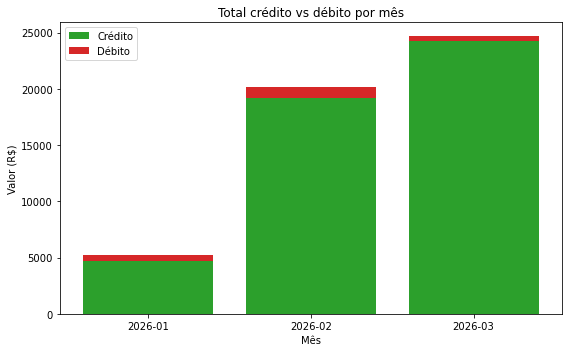

In [5]:
# Gerar gráfico empilhado (crédito vs débito) e salvar
plt.figure(figsize=(8,5))
ax = plt.bar(summary['mes'], summary['total_credito'], label='Crédito', color='#2ca02c')
ax2 = plt.bar(summary['mes'], summary['total_debito'], bottom=summary['total_credito'], label='Débito', color='#d62728')
plt.title('Total crédito vs débito por mês')
plt.xlabel('Mês')
plt.ylabel('Valor (R$)')
plt.legend()
plt.tight_layout()
plt.savefig('grafico.png')
print('grafico.png salvo')

### Observações finais
- O notebook usa `pandas` para acelerar agregações.
- Execute as células em ordem; ao final `grafico.png` e `relatorio_pandas.json` estarão na pasta `clearbank-analise`.